# Jumanji Cleaner with TorchRL PPO: student version

This is the exercise version of the seminar notebook. It walks through Jumanji Cleaner, TorchRL TensorDict rollouts, PPO training, and an inter-agent cross-entropy diversity bonus.

Some cells intentionally contain `YOUR CODE HERE` and raise `NotImplementedError`. Fill those cells during the seminar. The complete implementation is in `notebooks/cleaner_torchrl_ppo_seminar.ipynb`.

In [1]:
%matplotlib inline

import csv
import json
import math
import os
import time
from dataclasses import asdict, dataclass
from functools import cached_property
from pathlib import Path
from typing import Any, Literal

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

'false'

## A quick look at Jumanji Cleaner

Jumanji environments are JAX environments. `reset` returns a JAX state and a timestep. For Cleaner, the observation contains the integer grid, agent locations, an action mask, and the current step count.

In [2]:
import jumanji
import jax
import jax.numpy as jnp

%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib import animation
import chex

jax_devices = jax.devices()
jnp.asarray(0, dtype=jnp.int8).block_until_ready()
print("JAX devices:", jax_devices)

JAX devices: [CudaDevice(id=0)]


In [3]:
base_cleaner = jumanji.make("Cleaner-v0")
key = jax.random.PRNGKey(0)
state, timestep = base_cleaner.reset(key)
print(base_cleaner)
print("grid shape:", timestep.observation.grid.shape)
print("agents_locations shape:", timestep.observation.agents_locations.shape)
print("action_mask shape:", timestep.observation.action_mask.shape)
print("step_count:", int(timestep.observation.step_count))
print("reward:", float(timestep.reward), "discount:", float(timestep.discount))

Cleaner(
	num_rows=10,
	num_cols=10,
	num_agents=3, 
	generator=<jumanji.environments.routing.cleaner.generator.RandomGenerator object at 0x7f98c02f5110>, 
)
grid shape: (10, 10)
agents_locations shape: (3, 2)
action_mask shape: (3, 4)
step_count: 0
reward: 0.0 discount: 1.0


In [4]:
def plot_grid(grid, agents_locations=None, title="Cleaner grid"):
    grid_np = jnp.asarray(grid)
    fig, ax = plt.subplots(figsize=(4, 4))
    cmap = plt.matplotlib.colors.ListedColormap(["#8b8b8b", "#f8f8f8", "#222222"])
    ax.imshow(grid_np, cmap=cmap, vmin=0, vmax=2)
    if agents_locations is not None:
        loc = jnp.asarray(agents_locations)
        ax.scatter(loc[:, 1], loc[:, 0], c="#d62728", s=90, edgecolors="white", linewidths=1.0)
        for idx, (row, col) in enumerate(loc):
            ax.text(int(col), int(row), str(idx), color="white", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.tight_layout()
    # plt.show()
    return fig, ax

(<Figure size 400x400 with 1 Axes>, <Axes: title={'center': 'Cleaner grid'}>)

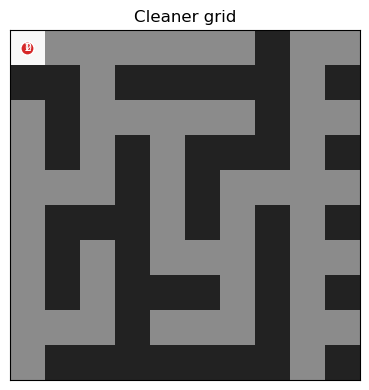

In [5]:
plot_grid(timestep.observation.grid, timestep.observation.agents_locations)

## Random policy rollout in raw Jumanji

Before training anything, run a random valid policy directly in Jumanji. The only rule is that each agent samples one action from its own `action_mask`. The environment still handles the transition and reward.

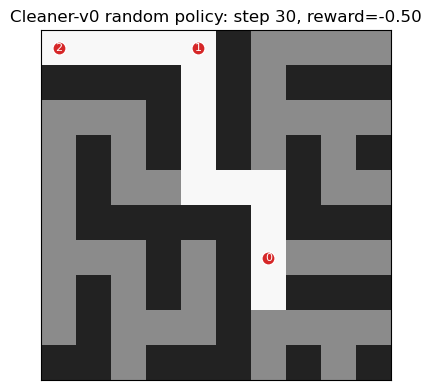

In [6]:
from IPython.display import clear_output, display


def sample_valid_jumanji_actions(action_mask, key):
    """Sample one valid discrete action per agent from a Jumanji Cleaner action mask."""
    mask = jnp.asarray(action_mask)
    num_agents, num_actions = mask.shape
    keys = jax.random.split(key, num_agents)

    def sample_one(agent_key, valid_actions):
        # Invalid actions get a very negative logit, so categorical samples only valid moves.
        logits = jnp.where(valid_actions, 0.0, -1.0e9)
        return jax.random.categorical(agent_key, logits).astype(jnp.int32)

    return jax.vmap(sample_one)(keys, mask), jax.random.fold_in(key, 1)


def show_jumanji_random_rollout(env, key, steps=8, delay=0.35, title="Random policy"):
    """Render a short Jumanji rollout step by step inside the notebook."""
    state, timestep = env.reset(key)
    key = jax.random.fold_in(key, 123)
    for step_idx in range(steps + 1):
        fig, _ = plot_grid(
            timestep.observation.grid,
            timestep.observation.agents_locations,
            f"{title}: step {step_idx}, reward={float(timestep.reward):.2f}",
        )
        plt.show()
        time.sleep(delay)
        clear_output(wait=True)
        # plt.close(fig)
        if step_idx == steps or bool(timestep.last()):
            break
        action, key = sample_valid_jumanji_actions(timestep.observation.action_mask, key)
        state, timestep = env.step(state, action)

show_jumanji_random_rollout(base_cleaner, jax.random.PRNGKey(42), steps=30, delay=0.2, title="Cleaner-v0 random policy")

## Using Cleaner with a custom generator

Jumanji `Cleaner` accepts a `Generator`. A generator is responsible for creating the initial `State`: the grid, agent positions, and environment key.

In [7]:
from jumanji import specs
from jumanji.environments.routing.cleaner.constants import CLEAN, DIRTY, MOVES, WALL
from jumanji.environments.routing.cleaner.env import Cleaner
from jumanji.environments.routing.cleaner.generator import Generator
from jumanji.environments.routing.cleaner.types import Observation, State
from jumanji.types import TimeStep, restart

from jumanji.environments.routing.cleaner.env import Cleaner

(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'Fixed seminar layout'}>)

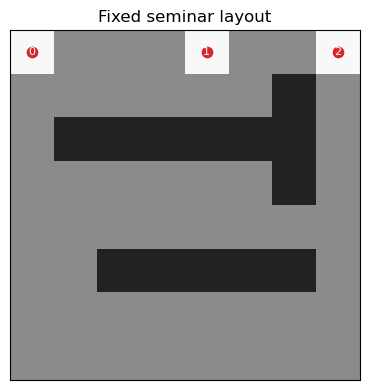

In [8]:
class FixedObstacleGenerator(Generator):
    """Deterministic Cleaner layout used in the seminar."""

    def __init__(self, height: int = 8, width: int = 8, num_agents: int = 3) -> None:
        if height < 6:
            raise ValueError("height must be at least 6")
        if width < 6:
            raise ValueError("width must be at least 6")
        if num_agents < 1:
            raise ValueError("num_agents must be at least 1")
        super().__init__(num_rows=height, num_cols=width, num_agents=num_agents)
        self.height = height
        self.width = width

    def __call__(self, key: chex.PRNGKey) -> State:
        grid = jnp.full((self.height, self.width), DIRTY, dtype=jnp.int8)
        grid = self._add_walls(grid)
        agents_locations = self._agent_start_locations()
        grid = grid.at[agents_locations[:, 0], agents_locations[:, 1]].set(CLEAN)
        return State(
            grid=grid,
            agents_locations=agents_locations,
            action_mask=None,
            step_count=jnp.array(0, dtype=jnp.int32),
            key=key,
        )

    def _add_walls(self, grid: chex.Array) -> chex.Array:
        upper_row = max(1, self.height // 3)
        lower_row = min(self.height - 2, (2 * self.height) // 3)
        vertical_col = min(self.width - 2, max(2, (3 * self.width) // 4))
        upper_start = max(1, self.width // 5)
        upper_end = min(self.width - 1, max(upper_start + 2, (4 * self.width) // 5))
        lower_start = max(1, self.width // 4)
        lower_end = self.width - 1
        vertical_start = max(1, self.height // 5)
        vertical_end = min(self.height - 1, max(vertical_start + 2, self.height // 2))
        grid = grid.at[upper_row, upper_start:upper_end].set(WALL)
        grid = grid.at[lower_row, lower_start:lower_end].set(WALL)
        grid = grid.at[vertical_start:vertical_end, vertical_col].set(WALL)
        return grid

    def _agent_start_locations(self) -> chex.Array:
        if self.num_agents == 1:
            cols = jnp.array([0], dtype=jnp.int32)
        else:
            agent_ids = jnp.arange(self.num_agents, dtype=jnp.float32)
            cols = jnp.rint(agent_ids * (self.width - 1) / (self.num_agents - 1)).astype(jnp.int32)
        rows = jnp.zeros((self.num_agents,), dtype=jnp.int32)
        return jnp.stack([rows, cols], axis=-1)

fixed_state = FixedObstacleGenerator(height=8, width=8, num_agents=3)(jax.random.PRNGKey(1))
plot_grid(fixed_state.grid, fixed_state.agents_locations, "Fixed seminar layout")

action_mask shape: (3, 4)
time_limit: 64


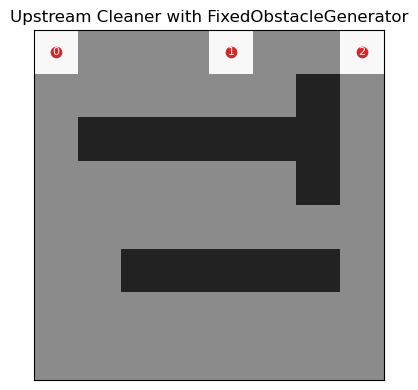

In [9]:
# A normal Cleaner can already be constructed with any Jumanji Cleaner generator.
# We use the upstream class here to separate the generator idea from the later TorchRL compatibility fixes.
cleaner_env = Cleaner(
    generator=FixedObstacleGenerator(height=8, width=8, num_agents=3),
    time_limit=64,
    penalty_per_timestep=0.1,
)
state, timestep = cleaner_env.reset(jax.random.PRNGKey(3))
plot_grid(timestep.observation.grid, timestep.observation.agents_locations, "Upstream Cleaner with FixedObstacleGenerator")
print("action_mask shape:", timestep.observation.action_mask.shape)
print("time_limit:", cleaner_env.time_limit)

## The TorchRL-compatible Cleaner subclass

TorchRL converts Jumanji specs into TensorDict specs. The custom subclass keeps rectangular action masks correct and gives `agents_locations` bounds with shape `(num_agents, 2)`, which TorchRL's converter expects.

ObservationSpec(
	grid=BoundedArray(shape=(8, 8), dtype=dtype('int8'), name='grid', minimum=Array(0, dtype=int8), maximum=Array(2, dtype=int8)),
	agents_locations=BoundedArray(shape=(3, 2), dtype=dtype('int32'), name='agents_locations', minimum=Array([[0, 0],
       [0, 0],
       [0, 0]], dtype=int32), maximum=Array([[8, 8],
       [8, 8],
       [8, 8]], dtype=int32)),
	action_mask=BoundedArray(shape=(3, 4), dtype=dtype('bool'), name='action_mask', minimum=Array(False, dtype=bool), maximum=Array(True, dtype=bool)),
	step_count=BoundedArray(shape=(), dtype=dtype('int32'), name='step_count', minimum=Array(0, dtype=int32), maximum=Array(64, dtype=int32)),
)
action mask for agents:
 [[False  True  True False]
 [False  True  True  True]
 [False False  True  True]]


(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'CustomCleaner reset'}>)

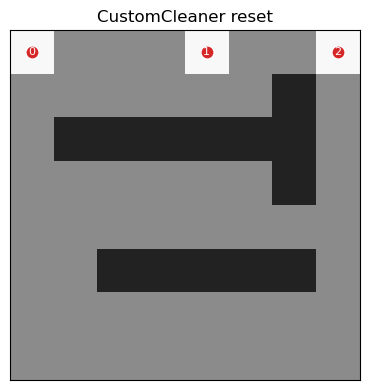

In [11]:
class CustomCleaner(Cleaner):
    """Cleaner variant with custom starts, rectangular masks, and TorchRL-friendly specs."""

    @cached_property
    def observation_spec(self) -> specs.Spec[Observation]:
        grid = specs.BoundedArray(self.grid_shape, jnp.int8, 0, 2, "grid")
        min_locations = jnp.zeros((self.num_agents, 2), dtype=jnp.int32)
        max_locations = jnp.broadcast_to(jnp.asarray(self.grid_shape, dtype=jnp.int32), (self.num_agents, 2))
        agents_locations = specs.BoundedArray(
            (self.num_agents, 2),
            jnp.int32,
            min_locations,
            max_locations,
            "agents_locations",
        )
        action_mask = specs.BoundedArray((self.num_agents, 4), bool, False, True, "action_mask")
        step_count = specs.BoundedArray((), jnp.int32, 0, self.time_limit, "step_count")
        return specs.Spec(
            Observation,
            "ObservationSpec",
            grid=grid,
            agents_locations=agents_locations,
            action_mask=action_mask,
            step_count=step_count,
        )

    def reset(self, key: chex.PRNGKey) -> tuple[State, TimeStep[Observation]]:
        state = self.generator(key)
        state.action_mask = self._compute_action_mask(state.grid, state.agents_locations)
        observation = self._observation_from_state(state)
        extras = self._compute_extras(state)
        return state, restart(observation, extras)

    def _compute_action_mask(self, grid: chex.Array, agents_locations: chex.Array) -> chex.Array:
        def is_move_valid(agent_location: chex.Array, move: chex.Array) -> chex.Array:
            y, x = agent_location + move
            in_bounds = (y >= 0) & (y < self.num_rows) & (x >= 0) & (x < self.num_cols)
            y_safe = jnp.clip(y, 0, self.num_rows - 1)
            x_safe = jnp.clip(x, 0, self.num_cols - 1)
            return in_bounds & (grid[y_safe, x_safe] != WALL)
        return jax.vmap(jax.vmap(is_move_valid, in_axes=(None, 0)), in_axes=(0, None))(agents_locations, MOVES)

custom_env = CustomCleaner(
    generator=FixedObstacleGenerator(height=8, width=8, num_agents=3),
    time_limit=64,
    penalty_per_timestep=0.1,
)
state, timestep = custom_env.reset(jax.random.PRNGKey(2))
print(custom_env.observation_spec)
print("action mask for agents:\n", timestep.observation.action_mask)
plot_grid(timestep.observation.grid, timestep.observation.agents_locations, "CustomCleaner reset")

## CustomCleaner rollout with the fixed layout

For TorchRL we will use `CustomCleaner`, because it fixes rectangular-grid action masks and exposes TorchRL-friendly observation specs. Behavior is still the same Cleaner task: agents move around the grid and clean dirty cells.

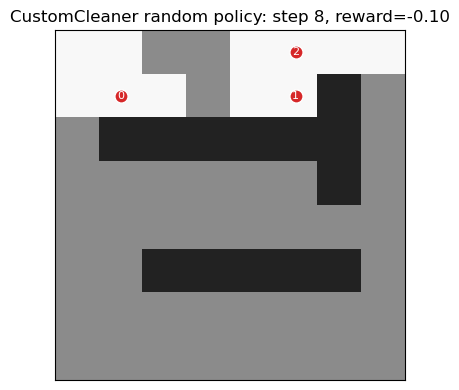

In [12]:
show_jumanji_random_rollout(custom_env, jax.random.PRNGKey(7), steps=8, delay=0.2, title="CustomCleaner random policy")

## Wrapping Jumanji with TorchRL

`JumanjiWrapper` exposes the JAX environment as a TorchRL environment. The data is a TensorDict: nested keys such as `('next', 'reward')` are normal in TorchRL rollouts.

In [13]:
import torch
from tensordict import TensorDict
from tensordict.nn import InteractionType, TensorDictModule, TensorDictSequential, set_interaction_type
from torch import nn
from torchrl.collectors import Collector
from torchrl.envs import JumanjiWrapper, TransformedEnv
from torchrl.envs.transforms import RewardSum
from torchrl.envs.utils import check_env_specs
from torchrl.modules import MaskedCategorical, ProbabilisticActor
from torchrl.objectives import ClipPPOLoss, ValueEstimators


print("Torch:", torch.__version__)
print("Torch CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", DEVICE)

Torch: 2.5.1
Torch CUDA available: True
Torch CUDA version: 11.8
Torch device: cuda


In [14]:
def build_torchrl_env(height=8, width=8, num_agents=3, num_envs=4, seed=0, penalty_per_timestep=0.1, device=DEVICE):
    generator = FixedObstacleGenerator(height=height, width=width, num_agents=num_agents)
    cleaner = CustomCleaner(
        generator=generator,
        time_limit=height * width,
        penalty_per_timestep=penalty_per_timestep,
    )
    base_env = JumanjiWrapper(
        cleaner,
        batch_size=[num_envs],
        categorical_action_encoding=True,
        jit=True,
        device=device,
    )
    env = TransformedEnv(base_env, RewardSum(in_keys=[base_env.reward_key], out_keys=["episode_reward"]))
    env.set_seed(seed)
    return env

wrapped_env = build_torchrl_env(num_envs=4, seed=0)
reset_td = wrapped_env.reset()
print("reset batch size:", reset_td.batch_size)
print("reset keys:", list(reset_td.keys(include_nested=True, leaves_only=True)))
print("grid:", reset_td["grid"].shape, reset_td["grid"].dtype)
print("agents_locations:", reset_td["agents_locations"].shape)
print("action_mask:", reset_td["action_mask"].shape)
print("action spec:", wrapped_env.action_spec)
rollout = wrapped_env.rollout(4)
print("rollout batch size:", rollout.batch_size)
print("rollout reward shape:", rollout[("next", "reward")].shape)
print("rollout done shape:", rollout[("next", "done")].shape)

/home/apshenitsyn/hse_marl/seminar/MARL-Intro/.pixi/envs/default/lib/python3.11/site-packages/torchrl/envs/libs/jumanji.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647369228/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  torch.as_tensor(np.asarray(spec.num_values)), dtype=dtype, device=device


reset batch size: torch.Size([4])
reset keys: ['grid', 'agents_locations', 'action_mask', 'step_count', 'done', 'terminated', ('state', 'grid'), ('state', 'agents_locations'), ('state', 'action_mask'), ('state', 'step_count'), ('state', 'key'), 'episode_reward']
grid: torch.Size([4, 8, 8]) torch.int8
agents_locations: torch.Size([4, 3, 2])
action_mask: torch.Size([4, 3, 4])
action spec: MultiCategorical(
    shape=torch.Size([4, 3]),
    space=BoxList(boxes=[BoxList(boxes=[CategoricalBox(n=4), CategoricalBox(n=4), CategoricalBox(n=4), CategoricalBox(n=4)]), BoxList(boxes=[CategoricalBox(n=4), CategoricalBox(n=4), CategoricalBox(n=4), CategoricalBox(n=4)]), BoxList(boxes=[CategoricalBox(n=4), CategoricalBox(n=4), CategoricalBox(n=4), CategoricalBox(n=4)])]),
    device=cuda:0,
    dtype=torch.int32,
    domain=discrete)
rollout batch size: torch.Size([4, 1])
rollout reward shape: torch.Size([4, 1, 1])
rollout done shape: torch.Size([4, 1, 1])


## What each agent sees

The current CNN policy does not consume raw integer values `0/1/2`. It uses binary spatial channels. By default each actor gets: dirty cells, walls, its own position, and all-agent occupancy. So every agent sees that other agents exist, but not as separately named identities unless we add an optional `other_agents` channel.

In [15]:
class CleanerObservationBuilder(nn.Module):
    """Build flat legacy observations and CNN spatial observations from Cleaner TensorDict keys."""

    def __init__(self, height: int, width: int, num_agents: int, obs_clean_channel=False, obs_other_channel=False) -> None:
        super().__init__()
        self.height = height
        self.width = width
        self.num_agents = num_agents
        self.obs_clean_channel = obs_clean_channel
        self.obs_other_channel = obs_other_channel

    def forward(self, grid, agents_locations, step_count, action_mask):
        leading_shape = grid.shape[:-2]
        normalizer = torch.tensor([max(self.height - 1, 1), max(self.width - 1, 1)], device=grid.device, dtype=torch.float32)
        grid_features = grid.float().flatten(-2, -1) / float(WALL)
        own_locations = agents_locations.float() / normalizer
        all_locations = own_locations.flatten(-2, -1)
        step = (step_count.float() / float(self.height * self.width)).reshape(*leading_shape, 1)

        global_observation = torch.cat([grid_features, all_locations, step], dim=-1)
        shared_local = torch.cat([grid_features, step], dim=-1).unsqueeze(-2).expand(*leading_shape, self.num_agents, -1)
        agent_observation = torch.cat([shared_local, own_locations, action_mask.float()], dim=-1)

        dirty = (grid == DIRTY).float()
        clean = (grid == CLEAN).float()
        wall = (grid == WALL).float()
        agent_maps = self._agent_position_maps(agents_locations, grid.device)
        own_maps = agent_maps
        all_agents_map = agent_maps.sum(dim=-3, keepdim=True)
        other_maps = all_agents_map - own_maps

        actor_base_channels = [dirty, wall]
        if self.obs_clean_channel:
            actor_base_channels.append(clean)
        actor_base = torch.stack(actor_base_channels, dim=-3)
        actor_base_per_agent = actor_base.unsqueeze(-4).expand(*leading_shape, self.num_agents, len(actor_base_channels), self.height, self.width)
        actor_agent_channels = [own_maps.unsqueeze(-3), all_agents_map.expand_as(own_maps).unsqueeze(-3)]
        if self.obs_other_channel:
            actor_agent_channels.append(other_maps.unsqueeze(-3))
        spatial_observation = torch.cat([actor_base_per_agent, *actor_agent_channels], dim=-3)

        critic_channels = [dirty, wall, all_agents_map.squeeze(-3)]
        if self.obs_clean_channel:
            critic_channels.append(clean)
        global_spatial_observation = torch.stack(critic_channels, dim=-3)
        return agent_observation, spatial_observation, action_mask.bool(), global_observation, global_spatial_observation, step

    def _agent_position_maps(self, agents_locations, device):
        flat_shape = agents_locations.shape[:-2]
        flat_locations = agents_locations.reshape(-1, self.num_agents, 2).long()
        rows = flat_locations[..., 0].clamp(0, self.height - 1)
        cols = flat_locations[..., 1].clamp(0, self.width - 1)
        flat_indices = rows * self.width + cols
        maps = torch.nn.functional.one_hot(flat_indices, num_classes=self.height * self.width)
        return maps.to(device=device, dtype=torch.float32).reshape(*flat_shape, self.num_agents, self.height, self.width)

obs_builder = CleanerObservationBuilder(8, 8, 3).to(DEVICE)
agent_obs, spatial_obs, mask, global_obs, global_spatial_obs, step_feature = obs_builder(
    reset_td["grid"], reset_td["agents_locations"], reset_td["step_count"], reset_td["action_mask"]
)
print("agent flat observation:", agent_obs.shape)
print("agent spatial observation:", spatial_obs.shape)
print("critic global spatial observation:", global_spatial_obs.shape)
print("step feature:", step_feature.shape)

agent flat observation: torch.Size([4, 3, 71])
agent spatial observation: torch.Size([4, 3, 4, 8, 8])
critic global spatial observation: torch.Size([4, 3, 8, 8])
step feature: torch.Size([4, 1])


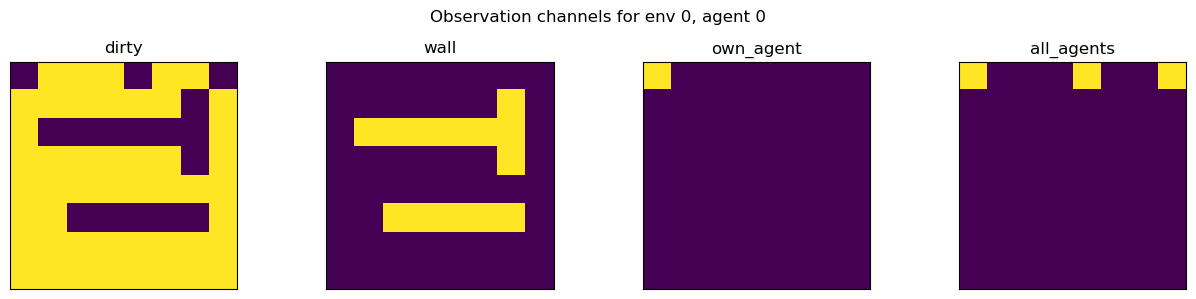

In [16]:
def show_agent_channels(spatial_obs, env_idx=0, agent_idx=0, names=("dirty", "wall", "own_agent", "all_agents")):
    channels = spatial_obs[env_idx, agent_idx].detach().cpu()
    fig, axes = plt.subplots(1, channels.shape[0], figsize=(3.2 * channels.shape[0], 3))
    if channels.shape[0] == 1:
        axes = [axes]
    for ax, channel, name in zip(axes, channels, names):
        ax.imshow(channel, cmap="viridis", vmin=0, vmax=max(1.0, float(channel.max())))
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"Observation channels for env {env_idx}, agent {agent_idx}")
    fig.tight_layout()
    plt.show()

show_agent_channels(spatial_obs, env_idx=0, agent_idx=0)

## CNN actor and centralized critic

For the seminar defaults, actors are decentralized and do not share parameters. The critic is centralized and shares one value function. This is a MAPPO-style training setup with decentralized execution.

The key tensor convention is `[..., num_agents, channels, height, width]` for actor observations. Inside the actor loop, `spatial_observation[..., agent_idx, :, :, :]` selects the channels for one agent while preserving all leading batch dimensions.

## Exercise 1: CNN encoder

Complete `SpatialCNNEncoder.__init__`. This is the image-like encoder used by both the per-agent actor and the centralized critic.

Your implementation must create `self.net`. It should accept a tensor of shape `[batch, channels, height, width]` and return `[batch, hidden_size]`.

In [17]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    height: int = 8
    width: int = 8
    num_agents: int = 3
    num_envs: int = 16
    n_iters: int = 8
    frames_per_batch: int = 512
    ppo_epochs: int = 2
    minibatch_size: int = 128
    hidden_size: int = 128
    penalty_per_timestep: float = 0.1
    lr: float = 5.0e-4
    gamma: float = 0.995
    lmbda: float = 0.95
    clip_epsilon: float = 0.2
    entropy_coeff: float = 1.0e-4
    critic_coeff: float = 1.0
    max_grad_norm: float = 1.0
    diversity_coeff: float = 0.0
    diversity_pairs: Literal["all", "adjacent", "sampled"] = "all"
    diversity_source_grad: bool = False
    diversity_sampled_pairs: int = 8
    diversity_bonus_max: float = 3.0
    share_policy_params: bool = False
    critic_centralized: bool = True
    eval_rollout_length: int = 64
    early_stop_mode_success: float = 0.95
    early_stop_sample_success: float = 0.85
    early_stop_patience: int = 5
    early_stop_min_mode_success: float = 0.95
    early_stop_min_sample_success: float = 0.75
    output_dir: str = ".artifacts/notebook_cleaner_ppo"


class PerAgentMaskedCategorical(MaskedCategorical):
    """MaskedCategorical variant that keeps one log-probability per agent."""

    def log_prob(self, value):
        return super().log_prob(value)

    def entropy(self):
        return super().entropy()



class SpatialCNNEncoder(nn.Module):
    """Encode a stack of grid channels into a fixed-size vector.

    Exercise contract:
    - input to forward: observation with shape [..., channels, height, width];
    - forward flattens leading dimensions and calls self.net on [batch, channels, height, width];
    - self.net must return [batch, hidden_size];
    - forward reshapes it back to [..., hidden_size].

    Implement the same architecture used in the instructor notebook:
    Conv2d(in_channels, 32, kernel_size=3, padding=1), ReLU,
    Conv2d(32, 32, kernel_size=3, padding=1), ReLU,
    Flatten,
    Linear(32 * height * width, hidden_size), ReLU.
    """

    def __init__(self, in_channels: int, height: int, width: int, hidden_size: int) -> None:
        super().__init__()
        # YOUR CODE HERE
        # Define self.net as an nn.Sequential that maps [B, C, H, W] -> [B, hidden_size].
        raise NotImplementedError("YOUR CODE HERE: build the CNN encoder architecture")

    def forward(self, observation):
        # observation has shape [..., channels, height, width]. Conv2d expects [batch, C, H, W].
        leading_shape = observation.shape[:-3]
        flat = observation.reshape(-1, *observation.shape[-3:])
        encoded = self.net(flat)
        return encoded.reshape(*leading_shape, encoded.shape[-1])


class CleanerCNNPolicyNet(nn.Module):
    """Decentralized CNN actor; optionally parameter-shared across agents."""

    def __init__(self, config: TrainConfig) -> None:
        super().__init__()
        self.num_agents = config.num_agents
        self.share_params = config.share_policy_params
        in_channels = 4  # dirty, wall, own-agent map, all-agents map
        side_dim = 1 + 4  # normalized step count plus the four-action mask
        if self.share_params:
            self.encoders = nn.ModuleList([SpatialCNNEncoder(in_channels, config.height, config.width, config.hidden_size)])
            self.heads = nn.ModuleList([nn.Linear(config.hidden_size + side_dim, 4)])
        else:
            self.encoders = nn.ModuleList([SpatialCNNEncoder(in_channels, config.height, config.width, config.hidden_size) for _ in range(config.num_agents)])
            self.heads = nn.ModuleList([nn.Linear(config.hidden_size + side_dim, 4) for _ in range(config.num_agents)])

    def forward(self, spatial_observation, step_feature, action_mask):
        # spatial_observation: [..., num_agents, channels, height, width]
        # step_feature: [..., 1]. Expand it to one scalar per agent: [..., num_agents, 1].
        step_per_agent = step_feature.unsqueeze(-2).expand(*spatial_observation.shape[:-4], self.num_agents, 1)
        side = torch.cat([step_per_agent, action_mask.float()], dim=-1)

        logits = []
        for agent_idx in range(self.num_agents):
            module_idx = 0 if self.share_params else agent_idx
            # Select this agent's grid channels, keeping all leading batch dimensions intact.
            agent_grid = spatial_observation[..., agent_idx, :, :, :]
            embedding = self.encoders[module_idx](agent_grid)
            agent_logits = self.heads[module_idx](torch.cat([embedding, side[..., agent_idx, :]], dim=-1))
            logits.append(agent_logits)
        # Stack back to [..., num_agents, num_actions]. TorchRL will pass this to MaskedCategorical.
        return torch.stack(logits, dim=-2)


class CleanerCNNCriticNet(nn.Module):
    """Centralized CNN critic over global grid channels."""

    def __init__(self, config: TrainConfig) -> None:
        super().__init__()
        # Critic channels: dirty, wall, all-agents map. It does not need per-agent own maps.
        self.encoder = SpatialCNNEncoder(3, config.height, config.width, config.hidden_size)
        self.head = nn.Linear(config.hidden_size + 1, 1)

    def forward(self, spatial_observation, global_spatial_observation, step_feature):
        # global_spatial_observation: [..., 3, height, width]
        embedding = self.encoder(global_spatial_observation)
        return self.head(torch.cat([embedding, step_feature], dim=-1))

## TensorDict modules and probabilistic actor

TorchRL modules read from and write to TensorDict keys. The actor writes per-agent logits and samples masked categorical actions. The critic writes a single centralized `state_value`.

In [18]:
def make_observation_module(config: TrainConfig, device=DEVICE):
    return TensorDictModule(
        CleanerObservationBuilder(config.height, config.width, config.num_agents).to(device),
        in_keys=["grid", "agents_locations", "step_count", "action_mask"],
        out_keys=[
            ("agents", "observation"),
            ("agents", "spatial_observation"),
            ("agents", "action_mask"),
            "global_observation",
            "global_spatial_observation",
            "step_feature",
        ],
    )

def build_modules(config: TrainConfig, device=DEVICE):
    actor_obs = make_observation_module(config, device)
    critic_obs = make_observation_module(config, device)
    policy_net = CleanerCNNPolicyNet(config).to(device)
    critic_net = CleanerCNNCriticNet(config).to(device)
    policy_logits = TensorDictModule(
        policy_net,
        in_keys=[("agents", "spatial_observation"), "step_feature", ("agents", "action_mask")],
        out_keys=[("agents", "logits")],
    )
    critic_value = TensorDictModule(
        critic_net,
        in_keys=[("agents", "spatial_observation"), "global_spatial_observation", "step_feature"],
        out_keys=["state_value"],
    )
    actor_module = TensorDictSequential(actor_obs, policy_logits)
    actor = ProbabilisticActor(
        actor_module,
        in_keys={"logits": ("agents", "logits"), "mask": ("agents", "action_mask")},
        out_keys=["action"],
        distribution_class=PerAgentMaskedCategorical,
        return_log_prob=True,
        log_prob_key="sample_log_prob",
    )
    critic = TensorDictSequential(critic_obs, critic_value)
    return actor, critic, actor_module

config = TrainConfig()
torch.manual_seed(config.seed)
train_env = build_torchrl_env(config.height, config.width, config.num_agents, config.num_envs, config.seed, config.penalty_per_timestep)
actor, critic, actor_module = build_modules(config)
td = train_env.reset()
actor(td)
critic(td)
print("actor keys:", [key for key in td.keys(include_nested=True, leaves_only=True) if "agents" in str(key) or key in {"action", "sample_log_prob"}])
print("action shape:", td["action"].shape)
print("log prob shape:", td["sample_log_prob"].shape)
print("state_value shape:", td["state_value"].shape)

actor keys: ['agents_locations', ('state', 'agents_locations'), ('agents', 'observation'), ('agents', 'spatial_observation'), ('agents', 'action_mask'), ('agents', 'logits'), 'action', 'sample_log_prob']
action shape: torch.Size([16, 3])
log prob shape: torch.Size([16, 3])
state_value shape: torch.Size([16, 1])


/home/apshenitsyn/hse_marl/seminar/MARL-Intro/.pixi/envs/default/lib/python3.11/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


## TorchRL collector: one training batch

The collector owns the rollout loop. It repeatedly calls the TorchRL environment with the actor, stores actions/log-probabilities/rewards/dones in a TensorDict, and returns `frames_per_batch` environment transitions at a time.

In [19]:
collector_config = TrainConfig(num_envs=4, frames_per_batch=64, hidden_size=32)
collector_env = build_torchrl_env(
    collector_config.height,
    collector_config.width,
    collector_config.num_agents,
    collector_config.num_envs,
    collector_config.seed,
    collector_config.penalty_per_timestep,
)
collector_actor, collector_critic, collector_actor_module = build_modules(collector_config)
collector = Collector(
    collector_env,
    collector_actor,
    frames_per_batch=collector_config.frames_per_batch,
    total_frames=collector_config.frames_per_batch,
    device=DEVICE,
)
one_batch = next(iter(collector)).to(DEVICE)
print("batch_size:", one_batch.batch_size)
print("keys:", list(one_batch.keys(include_nested=True, leaves_only=True)))
print("action:", one_batch["action"].shape)
print("sample_log_prob:", one_batch["sample_log_prob"].shape)
print("next reward:", one_batch[("next", "reward")].shape)
print("next done:", one_batch[("next", "done")].shape)

batch_size: torch.Size([4, 16])
keys: [('state', 'grid'), ('state', 'agents_locations'), ('state', 'action_mask'), ('state', 'step_count'), ('state', 'key'), 'episode_reward', 'action', 'grid', 'agents_locations', 'action_mask', 'step_count', 'done', 'terminated', ('next', 'grid'), ('next', 'agents_locations'), ('next', 'action_mask'), ('next', 'step_count'), ('next', 'state', 'grid'), ('next', 'state', 'agents_locations'), ('next', 'state', 'action_mask'), ('next', 'state', 'step_count'), ('next', 'state', 'key'), ('next', 'episode_reward'), ('next', 'reward'), ('next', 'done'), ('next', 'terminated'), ('collector', 'traj_ids'), ('agents', 'action_mask'), ('agents', 'logits'), ('agents', 'spatial_observation'), ('agents', 'observation'), 'global_spatial_observation', 'step_feature', 'global_observation', 'sample_log_prob']
action: torch.Size([4, 16, 3])
sample_log_prob: torch.Size([4, 16, 3])
next reward: torch.Size([4, 16, 1])
next done: torch.Size([4, 16, 1])


## PPO loss and GAE on one batch

TorchRL separates data collection from loss computation. After a batch is collected, `ClipPPOLoss` can add GAE targets and compute the PPO objective, critic loss, and entropy term on a minibatch.

In [20]:
def normalize_value_estimator_shapes(batch: TensorDict, num_agents: int) -> None:
    """Make centralized value targets compatible with per-agent PPO log-probs."""
    advantage = batch.get("advantage", None)
    if advantage is not None:
        if advantage.ndim == len(batch.batch_size):
            advantage = advantage.unsqueeze(-1)
        if advantage.shape[-1] == 1:
            advantage = advantage.expand(*advantage.shape[:-1], num_agents)
        if advantage.ndim == len(batch.batch_size) + 1:
            advantage = advantage.unsqueeze(-1)
        batch.set("advantage", advantage)
    value_target = batch.get("value_target", None)
    if value_target is not None and value_target.ndim == len(batch.batch_size):
        batch.set("value_target", value_target.unsqueeze(-1))


def make_ppo_loss(actor, critic, config: TrainConfig):
    loss_module = ClipPPOLoss(
        actor_network=actor,
        critic_network=critic,
        clip_epsilon=config.clip_epsilon,
        entropy_coeff=config.entropy_coeff,
        critic_coeff=config.critic_coeff,
        normalize_advantage=False,
    )
    loss_module.set_keys(
        reward="reward",
        action="action",
        sample_log_prob="sample_log_prob",
        value="state_value",
        done="done",
        terminated="terminated",
    )
    loss_module.make_value_estimator(ValueEstimators.GAE, gamma=config.gamma, lmbda=config.lmbda)
    return loss_module

loss_module = make_ppo_loss(collector_actor, collector_critic, collector_config)
with torch.no_grad():
    loss_module.value_estimator(one_batch)
    normalize_value_estimator_shapes(one_batch, collector_config.num_agents)
flat_batch = one_batch.detach().reshape(-1)
minibatch = flat_batch[: collector_config.minibatch_size]
losses = loss_module(minibatch)
print("advantage:", one_batch["advantage"].shape)
print("value_target:", one_batch["value_target"].shape)
print("flat batch size:", flat_batch.batch_size)
print("loss keys:", list(losses.keys(include_nested=True, leaves_only=True)))
print({key: float(value.detach().mean().cpu()) for key, value in losses.items() if torch.is_tensor(value)})

advantage: torch.Size([4, 16, 3, 1])
value_target: torch.Size([4, 16, 1])
flat batch size: torch.Size([64])
loss keys: ['loss_objective', 'clip_fraction', 'kl_approx', 'entropy', 'loss_entropy', 'loss_critic', 'explained_variance', 'ESS', 'max_ratio', 'mean_ratio']
{'loss_objective': -4.149943828582764, 'clip_fraction': 0.0, 'kl_approx': 4.967053968130131e-08, 'entropy': 0.9305529594421387, 'loss_entropy': -9.305529238190502e-05, 'loss_critic': 3.812774658203125, 'explained_variance': -0.0007488727569580078, 'ESS': 0.9999998807907104, 'max_ratio': 1.0000059604644775, 'mean_ratio': 1.0}


## Basic PPO training loop

This first training loop is plain PPO: collect a batch, compute GAE, run PPO minibatch updates, evaluate in mode/sample mode, and update live learning curves. There is no diversity bonus in this block.

In [25]:
def completed_episode_return_mean(batch: TensorDict):
    dones = batch[("next", "done")].squeeze(-1).bool()
    episode_rewards = batch[("next", "episode_reward")].squeeze(-1)
    completed = episode_rewards[dones]
    if completed.numel() == 0:
        return float("nan"), 0
    return float(completed.mean().detach().cpu()), int(completed.numel())


def dirty_counts_from_grid(grid):
    return (grid == DIRTY).sum(dim=(-1, -2))


def summarize_eval_rollout(rollout, config: TrainConfig, prefix: str):
    rewards = rollout[("next", "reward")].sum(dim=1).squeeze(-1)
    next_grid = rollout[("next", "grid")]
    dirty_counts = dirty_counts_from_grid(next_grid)
    solved_by_step = dirty_counts == 0
    solved = solved_by_step.any(dim=1)
    first_solved_step = solved_by_step.float().argmax(dim=1).float() + 1.0
    timeout_step = torch.full_like(first_solved_step, float(config.eval_rollout_length))
    completion_step = torch.where(solved, first_solved_step, timeout_step)
    success_completion = completion_step[solved].mean() if solved.any() else torch.tensor(float("nan"), device=completion_step.device)
    non_wall_counts = (next_grid != WALL).sum(dim=(-1, -2)).clamp_min(1)
    final_dirty_fraction = dirty_counts[:, -1].float() / non_wall_counts[:, -1].float()
    return {
        f"{prefix}_return_mean": float(rewards.mean().detach().cpu()),
        f"{prefix}_success_rate": float(solved.float().mean().detach().cpu()),
        f"{prefix}_final_dirty_fraction": float(final_dirty_fraction.mean().detach().cpu()),
        f"{prefix}_completion_step_mean": float(completion_step.mean().detach().cpu()),
        f"{prefix}_completion_step_success_mean": float(success_completion.detach().cpu()),
    }


def evaluate_policy(env, actor, config: TrainConfig):
    with torch.no_grad(), set_interaction_type(InteractionType.MODE):
        mode_rollout = env.rollout(config.eval_rollout_length, policy=actor)
    with torch.no_grad(), set_interaction_type(InteractionType.RANDOM):
        sample_rollout = env.rollout(config.eval_rollout_length, policy=actor)
    return {
        **summarize_eval_rollout(mode_rollout, config, "eval_mode"),
        **summarize_eval_rollout(sample_rollout, config, "eval_sample"),
        "rollout": mode_rollout.detach().cpu(),
    }


def plot_training_metrics(metrics, title="Cleaner PPO", live=False):
    if not metrics:
        return
    frames = [row["frames"] for row in metrics]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(frames, [row["episode_return_mean"] for row in metrics], label="completed train episodes")
    axes[0].plot(frames, [row["eval_mode_return_mean"] for row in metrics], label="eval mode")
    axes[0].plot(frames, [row["eval_sample_return_mean"] for row in metrics], label="eval sample")
    axes[0].set_xlabel("environment steps")
    axes[0].set_ylabel("return")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(frames, [row["eval_mode_success_rate"] for row in metrics], label="mode success")
    axes[1].plot(frames, [row["eval_sample_success_rate"] for row in metrics], label="sample success")
    axes[1].plot(frames, [row["eval_sample_final_dirty_fraction"] for row in metrics], label="sample dirty fraction")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_xlabel("environment steps")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(frames, [row["eval_mode_completion_step_mean"] for row in metrics], label="mode completion step")
    axes[2].plot(frames, [row["eval_sample_completion_step_mean"] for row in metrics], label="sample completion step")
    axes[2].set_xlabel("environment steps")
    axes[2].set_ylabel("completion step")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    fig.suptitle(title)
    fig.tight_layout()
    if live:
        clear_output(wait=True)
        display(fig)
        plt.close(fig)
    else:
        plt.show()


def should_stop_early(metrics: list[dict[str, float]], config: TrainConfig):
    eval_rows = [
        row for row in metrics
        if math.isfinite(row.get("eval_mode_success_rate", float("nan")))
        and math.isfinite(row.get("eval_sample_success_rate", float("nan")))
    ]
    if len(eval_rows) < config.early_stop_patience:
        return False, {}
    window = eval_rows[-config.early_stop_patience:]
    mode_values = [row["eval_mode_success_rate"] for row in window]
    sample_values = [row["eval_sample_success_rate"] for row in window]
    stats = {
        "mode_mean": sum(mode_values) / len(mode_values),
        "sample_mean": sum(sample_values) / len(sample_values),
        "mode_min": min(mode_values),
        "sample_min": min(sample_values),
    }
    stop = (
        stats["mode_mean"] >= config.early_stop_mode_success
        and stats["sample_mean"] >= config.early_stop_sample_success
        and stats["mode_min"] >= config.early_stop_min_mode_success
        and stats["sample_min"] >= config.early_stop_min_sample_success
    )
    return stop, stats


def build_training_objects(config: TrainConfig):
    """Build mutable training objects outside the training function.

    The actor and critic returned here are the same objects updated by PPO. If a notebook
    cell is interrupted, these variables still point to the latest weights.
    """
    torch.manual_seed(config.seed)
    env = build_torchrl_env(config.height, config.width, config.num_agents, config.num_envs, config.seed, config.penalty_per_timestep)
    eval_env = build_torchrl_env(config.height, config.width, config.num_agents, config.num_envs, config.seed + 10_000, config.penalty_per_timestep)
    actor, critic, actor_module = build_modules(config)
    collector = Collector(env, actor, frames_per_batch=config.frames_per_batch, total_frames=config.frames_per_batch * config.n_iters, device=DEVICE)
    loss_module = make_ppo_loss(actor, critic, config)
    optimizer = torch.optim.Adam(loss_module.parameters(), lr=config.lr)
    return env, eval_env, actor, critic, actor_module, collector, loss_module, optimizer


def write_metrics_csv(output_dir: Path, metrics: list[dict[str, float]]) -> None:
    if not metrics:
        return
    output_dir.mkdir(parents=True, exist_ok=True)
    with (output_dir / "metrics.csv").open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(metrics[0].keys()))
        writer.writeheader()
        writer.writerows(metrics)


def make_metric_row(iteration, config, batch, episode_return, completed_episodes, eval_values, timings, grad_norm_value, last_losses, diversity_value=float("nan"), diversity_raw_value=float("nan")):
    return {
        "iter": iteration,
        "frames": iteration * config.frames_per_batch,
        "episode_return_mean": episode_return,
        "completed_episodes": completed_episodes,
        "collector_window_return_mean": float(batch[("next", "reward")].sum(dim=1).mean().detach().cpu()),
        "diversity_cross_entropy": diversity_value,
        "diversity_cross_entropy_raw": diversity_raw_value,
        "elapsed_sec": timings["elapsed_sec"],
        "loss_forward_sec": timings["loss_forward_sec"],
        "diversity_sec": timings.get("diversity_sec", 0.0),
        "backward_sec": timings["backward_sec"],
        "optimizer_sec": timings["optimizer_sec"],
        "grad_norm": grad_norm_value,
        **{key: value for key, value in eval_values.items() if key != "rollout"},
        **last_losses,
    }


def train_basic_ppo(config, env, eval_env, actor, critic, actor_module, collector, loss_module, optimizer, metrics=None, live_plot=True):
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "config.json").write_text(json.dumps(asdict(config), indent=2) + "\n")
    metrics = [] if metrics is None else metrics
    start_wall = time.perf_counter()
    start_iteration = len(metrics)

    for local_iteration, batch in enumerate(collector, start=1):
        iteration = start_iteration + local_iteration
        # 1. Collect one rollout batch with the current actor.
        batch = batch.to(DEVICE)
        episode_return, completed_episodes = completed_episode_return_mean(batch)

        # 2. Compute advantages and value targets with GAE.
        with torch.no_grad():
            loss_module.value_estimator(batch)
            normalize_value_estimator_shapes(batch, config.num_agents)
        flat_batch = batch.detach().reshape(-1)

        last_losses = {}
        grad_norm_value = 0.0
        loss_forward_sec = backward_sec = optimizer_sec = 0.0
        for _ in range(config.ppo_epochs):
            permutation = torch.randperm(flat_batch.numel(), device=DEVICE)
            for start in range(0, flat_batch.numel(), config.minibatch_size):
                minibatch = flat_batch[permutation[start:start + config.minibatch_size]]

                # 3. PPO objective: clipped policy loss + critic loss + entropy term.
                t0 = time.perf_counter()
                losses = loss_module(minibatch)
                total_loss = losses["loss_objective"] + losses["loss_critic"] + losses["loss_entropy"]
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                loss_forward_sec += time.perf_counter() - t0

                # 4. Backpropagate and update the same actor/critic objects created above.
                t0 = time.perf_counter()
                total_loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(loss_module.parameters(), config.max_grad_norm)
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                backward_sec += time.perf_counter() - t0
                grad_norm_value = float(grad_norm.detach().cpu())

                t0 = time.perf_counter()
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                optimizer_sec += time.perf_counter() - t0
                last_losses = {key: float(value.detach().mean().cpu()) for key, value in losses.items() if torch.is_tensor(value)}

        # 5. Evaluate and log. CSV is written every iteration, so interruption loses less work.
        eval_values = evaluate_policy(eval_env, actor, config)
        row = make_metric_row(
            iteration,
            config,
            batch,
            episode_return,
            completed_episodes,
            eval_values,
            {
                "elapsed_sec": time.perf_counter() - start_wall,
                "loss_forward_sec": loss_forward_sec,
                "diversity_sec": 0.0,
                "backward_sec": backward_sec,
                "optimizer_sec": optimizer_sec,
            },
            grad_norm_value,
            last_losses,
        )
        metrics.append(row)
        write_metrics_csv(output_dir, metrics)
        print(f"iter={iteration:03d} frames={row['frames']} sample_sr={row['eval_sample_success_rate']:.2f} elapsed={row['elapsed_sec']:.1f}s")
        if live_plot:
            plot_training_metrics(metrics, "Basic PPO", live=True)
        stop, stats = should_stop_early(metrics, config)
        if stop:
            print(f"early stop: mode_mean={stats['mode_mean']:.3f}, sample_mean={stats['sample_mean']:.3f}")
            break
        if iteration >= config.n_iters:
            break
    return metrics

def render_torchrl_actor_rollout(env, actor, config: TrainConfig, interaction_type=InteractionType.MODE, steps=None, delay=0.2, title="Trained actor"):
    from IPython.display import clear_output, display

    steps = config.eval_rollout_length if steps is None else steps
    with torch.no_grad(), set_interaction_type(interaction_type):
        rollout = env.rollout(steps, policy=actor).detach().cpu()
    grids = rollout[("next", "grid")][0]
    locations = rollout[("next", "agents_locations")][0]
    rewards = rollout[("next", "reward")][0].squeeze(-1)
    for step_idx in range(grids.shape[0]):
        fig, _ = plot_grid(
            grids[step_idx],
            locations[step_idx],
            f"{title}: step {step_idx + 1}, reward={float(rewards[step_idx]):.2f}",
        )
        plt.show()
        time.sleep(delay)
        clear_output(wait=True)
        # plt.close(fig)
    return rollout


## Run training

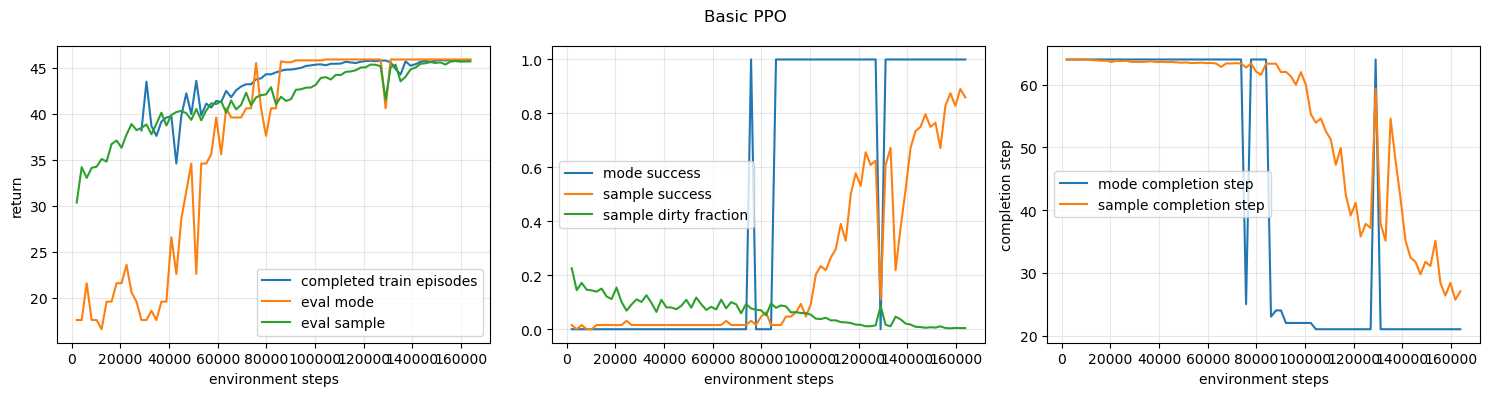

early stop: mode_mean=1.000, sample_mean=0.856


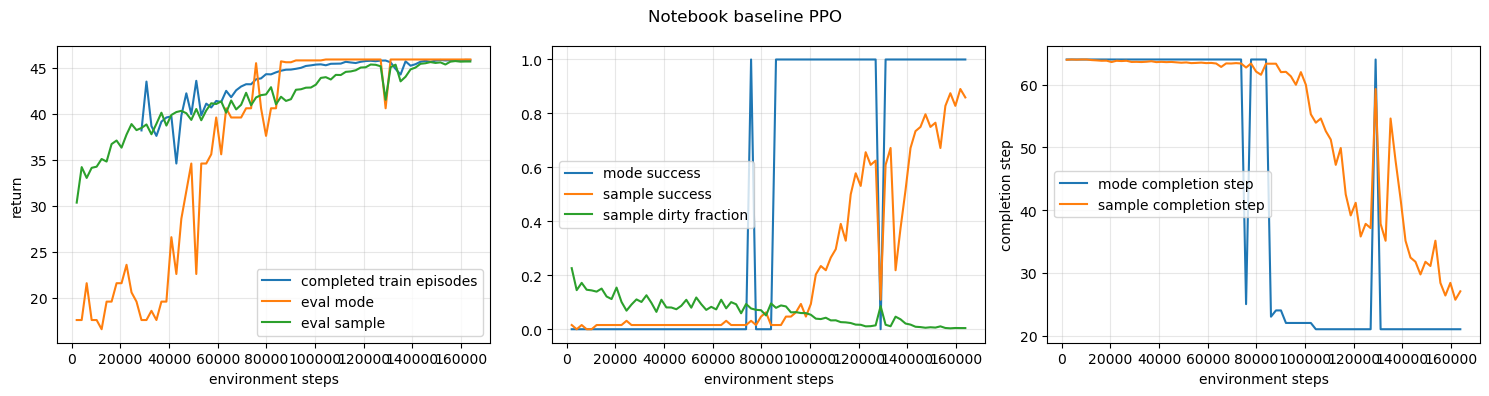

In [23]:
baseline_config = TrainConfig(
    seed=0,
    height=8,
    width=8,
    num_agents=3,
    num_envs=64,
    n_iters=300,
    frames_per_batch=2048,
    ppo_epochs=4,
    minibatch_size=256,
    hidden_size=128,
    diversity_coeff=0.0,
    output_dir=".artifacts/notebook_cleaner_baseline",
)
(
    baseline_env,
    baseline_eval_env,
    baseline_actor,
    baseline_critic,
    baseline_actor_module,
    baseline_collector,
    baseline_loss_module,
    baseline_optimizer,
) = build_training_objects(baseline_config)
baseline_metrics = []
baseline_metrics = train_basic_ppo(
    baseline_config,
    baseline_env,
    baseline_eval_env,
    baseline_actor,
    baseline_critic,
    baseline_actor_module,
    baseline_collector,
    baseline_loss_module,
    baseline_optimizer,
    metrics=baseline_metrics,
    live_plot=True,
)
plot_training_metrics(baseline_metrics, "Notebook baseline PPO")

## Render rollout with the trained baseline actor

Because `baseline_actor` was created before the training call, interrupting the training cell still leaves the current actor object available here. This cell renders the latest policy weights.

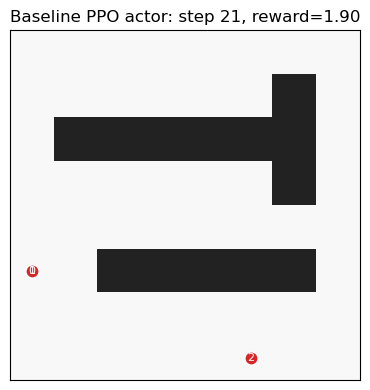

In [27]:
baseline_rollout = render_torchrl_actor_rollout(
    baseline_eval_env,
    baseline_actor,
    baseline_config,
    interaction_type=InteractionType.MODE,
    steps=baseline_config.eval_rollout_length,
    delay=0.12,
    title="Baseline PPO actor",
)

## Adding the inter-agent cross-entropy bonus

The PPO entropy term remains unchanged. The extra term below compares action distributions between agents. Maximizing cross-entropy encourages agents to put probability mass on different valid actions, but it can also add noise and compute cost.

## Exercises 2-4: inter-agent cross-entropy bonus

Complete the diversity bonus in three pieces:

1. `pair_indices`: decide which ordered agent pairs to compare.
2. `masked_cross_entropy_pair`: compute cross-entropy between two agents' masked action distributions.
3. `compute_diversity_bonus`: recompute actor logits on a PPO minibatch and aggregate CE over pairs.

The PPO entropy bonus already exists in TorchRL. This exercise adds a separate inter-agent term.

In [ ]:
def pair_indices(num_agents: int, mode: str, max_sampled_pairs: int, device):
    """Return ordered pairs of agents for the diversity bonus.

    Arguments:
    - num_agents: number of agents in the environment;
    - mode: one of "all", "adjacent", "sampled";
    - max_sampled_pairs: maximum number of pairs when mode == "sampled";
    - device: torch device used for random sampling.

    Expected behavior:
    - if num_agents < 2, return [];
    - "adjacent": [(0, 1), (1, 2), ...];
    - "all": all ordered pairs (i, j) where i != j;
    - "sampled": sample up to max_sampled_pairs from the all-pairs list.

    Return: a Python list of (source_agent, target_agent) tuples.
    """
    # YOUR CODE HERE
    raise NotImplementedError("YOUR CODE HERE: choose agent pairs")


def masked_cross_entropy_pair(source_logits, target_logits, source_mask, target_mask, detach_source=True):
    """Compute H(pi_source, pi_target) for one ordered pair of agents.

    Shapes:
    - source_logits, target_logits: [batch, 4];
    - source_mask, target_mask: [batch, 4] boolean valid-action masks.

    Expected behavior:
    - use actions valid for both agents when possible;
    - if there are no common valid actions for an item, fall back to actions valid for either agent;
    - mask invalid actions before softmax/log-softmax;
    - convert source logits to probabilities;
    - optionally detach source probabilities when detach_source=True;
    - return mean cross-entropy: -sum_a p_source(a) * log p_target(a).

    Return: scalar torch.Tensor.
    """
    # YOUR CODE HERE
    raise NotImplementedError("YOUR CODE HERE: compute masked cross-entropy")


def compute_diversity_bonus(actor_module, minibatch, config: TrainConfig, device=DEVICE):
    """Average masked cross-entropy over selected agent pairs.

    Expected behavior:
    - if config.diversity_coeff == 0 or num_agents < 2, return two scalar zeros;
    - select only env observation keys from minibatch: grid, agents_locations, step_count, action_mask;
    - run actor_module(td) to produce ("agents", "logits") and ("agents", "action_mask");
    - compute masked_cross_entropy_pair for every pair from pair_indices;
    - raw_bonus is the mean over pair CE values;
    - if config.diversity_bonus_max > 0, also return a clipped bonus used in the loss;
    - return (clipped_or_raw_bonus, raw_bonus).

    Return: tuple[torch.Tensor, torch.Tensor].
    """
    # YOUR CODE HERE
    raise NotImplementedError("YOUR CODE HERE: compute the diversity bonus")

## PPO training loop with the diversity extension

This duplicates the basic loop on purpose. The only conceptual change is the extra line `total_loss = total_loss - coeff * diversity_bonus`. Everything else stays PPO.

In [ ]:
def train_ppo_with_diversity(config, env, eval_env, actor, critic, actor_module, collector, loss_module, optimizer, metrics=None, live_plot=True):
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "config.json").write_text(json.dumps(asdict(config), indent=2) + "\n")
    metrics = [] if metrics is None else metrics
    start_wall = time.perf_counter()
    start_iteration = len(metrics)

    for local_iteration, batch in enumerate(collector, start=1):
        iteration = start_iteration + local_iteration
        batch = batch.to(DEVICE)
        episode_return, completed_episodes = completed_episode_return_mean(batch)
        with torch.no_grad():
            loss_module.value_estimator(batch)
            normalize_value_estimator_shapes(batch, config.num_agents)
        flat_batch = batch.detach().reshape(-1)

        last_losses = {}
        grad_norm_value = 0.0
        diversity_value = float("nan")
        diversity_raw_value = float("nan")
        loss_forward_sec = diversity_sec = backward_sec = optimizer_sec = 0.0
        for _ in range(config.ppo_epochs):
            permutation = torch.randperm(flat_batch.numel(), device=DEVICE)
            for start in range(0, flat_batch.numel(), config.minibatch_size):
                minibatch = flat_batch[permutation[start:start + config.minibatch_size]]

                t0 = time.perf_counter()
                losses = loss_module(minibatch)
                total_loss = losses["loss_objective"] + losses["loss_critic"] + losses["loss_entropy"]
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                loss_forward_sec += time.perf_counter() - t0

                # Diversity extension: maximize clipped inter-agent CE in addition to PPO entropy.
                if config.diversity_coeff:
                    t0 = time.perf_counter()
                    diversity_bonus, diversity_raw = compute_diversity_bonus(actor_module, minibatch, config)
                    total_loss = total_loss - config.diversity_coeff * diversity_bonus
                    if DEVICE.type == "cuda":
                        torch.cuda.synchronize()
                    diversity_sec += time.perf_counter() - t0
                    diversity_value = float(diversity_bonus.detach().cpu())
                    diversity_raw_value = float(diversity_raw.detach().cpu())

                t0 = time.perf_counter()
                total_loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(loss_module.parameters(), config.max_grad_norm)
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                backward_sec += time.perf_counter() - t0
                grad_norm_value = float(grad_norm.detach().cpu())

                t0 = time.perf_counter()
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                optimizer_sec += time.perf_counter() - t0
                last_losses = {key: float(value.detach().mean().cpu()) for key, value in losses.items() if torch.is_tensor(value)}

        eval_values = evaluate_policy(eval_env, actor, config)
        row = make_metric_row(
            iteration,
            config,
            batch,
            episode_return,
            completed_episodes,
            eval_values,
            {
                "elapsed_sec": time.perf_counter() - start_wall,
                "loss_forward_sec": loss_forward_sec,
                "diversity_sec": diversity_sec,
                "backward_sec": backward_sec,
                "optimizer_sec": optimizer_sec,
            },
            grad_norm_value,
            last_losses,
            diversity_value=diversity_value,
            diversity_raw_value=diversity_raw_value,
        )
        metrics.append(row)
        write_metrics_csv(output_dir, metrics)
        print(f"iter={iteration:03d} frames={row['frames']} sample_sr={row['eval_sample_success_rate']:.2f} ce={diversity_value:.3f} elapsed={row['elapsed_sec']:.1f}s")
        if live_plot:
            plot_training_metrics(metrics, "PPO with CE diversity", live=True)
        stop, stats = should_stop_early(metrics, config)
        if stop:
            print(f"early stop: mode_mean={stats['mode_mean']:.3f}, sample_mean={stats['sample_mean']:.3f}")
            break
        if iteration >= config.n_iters:
            break
    return metrics

## Run PPO with CE bonus

This repeats the same training structure, but adds the clipped inter-agent cross-entropy bonus to the PPO loss. The actor is again built before training, so `ce_actor` remains accessible if the cell is interrupted.

In [ ]:
ce_config = TrainConfig(
    seed=0,
    height=8,
    width=8,
    num_agents=3,
    num_envs=64,
    n_iters=300,
    frames_per_batch=2048,
    ppo_epochs=2,
    minibatch_size=256,
    hidden_size=128,
    diversity_coeff=0.001,
    diversity_pairs="all",
    output_dir=".artifacts/notebook_cleaner_ce0001",
)
(
    ce_env,
    ce_eval_env,
    ce_actor,
    ce_critic,
    ce_actor_module,
    ce_collector,
    ce_loss_module,
    ce_optimizer,
) = build_training_objects(ce_config)
ce_metrics = []
ce_metrics = train_ppo_with_diversity(
    ce_config,
    ce_env,
    ce_eval_env,
    ce_actor,
    ce_critic,
    ce_actor_module,
    ce_collector,
    ce_loss_module,
    ce_optimizer,
    metrics=ce_metrics,
    live_plot=True,
)
plot_training_metrics(ce_metrics, "Notebook PPO with CE diversity")

## Render rollout with the CE-trained actor

This uses the latest `ce_actor` weights, including if you manually stopped training early.

In [ ]:
ce_rollout = render_torchrl_actor_rollout(
    ce_eval_env,
    ce_actor,
    ce_config,
    interaction_type=InteractionType.MODE,
    steps=ce_config.eval_rollout_length,
    delay=0.12,
    title="CE PPO actor",
)